<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Classification_aircraft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")   # nano = fast, yolov8s.pt = more accurate

# Load image (replace with your own)
image_path = "/content/drive/MyDrive/20231219_145215.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Run detection
results = model(image)[0]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 384x640 2 airplanes, 1 truck, 291.1ms
Speed: 14.4ms preprocess, 291.1ms inference, 37.8ms postprocess per image at shape (1, 3, 384, 640)


In [4]:
TARGET_CLASSES = [0, 2, 4]  # person, car, airplane

for box in results.boxes:
    cls_id = int(box.cls[0])
    if cls_id in TARGET_CLASSES:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        label = model.names[cls_id]

        # Draw bounding box
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw label
        cv2.putText(
            image,
            f"{label} {conf:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

(np.float64(-0.5), np.float64(4031.5), np.float64(2267.5), np.float64(-0.5))

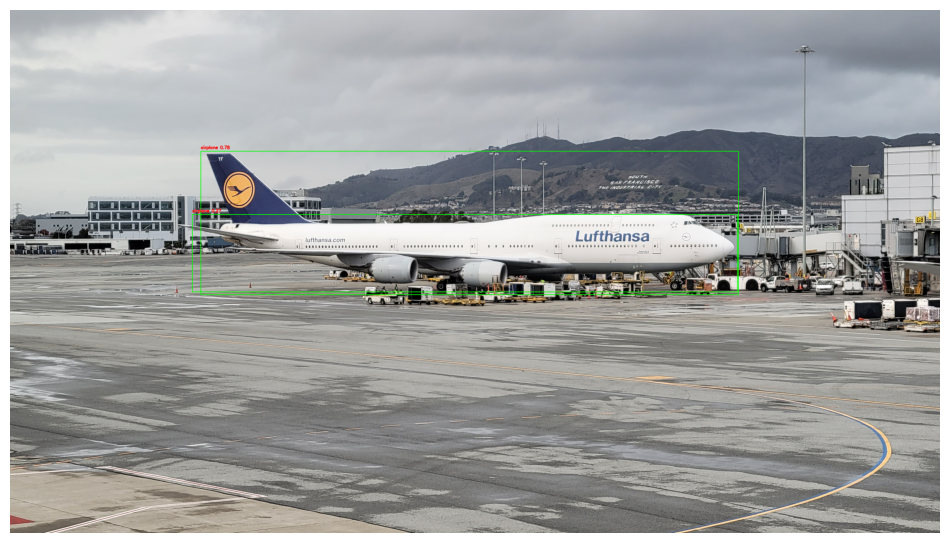

In [5]:
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")